In [3]:
import colorcet as cc
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from context_flux_no.simulations.pde.euler import Euler2D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField2D

2026-08-17 05:28:49,299 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [13]:
x, y = jnp.linspace(0, 1, 64), jnp.linspace(0, 1, 64)
grf = GaussianRandomField2D(gs.Gaussian(dim=2, var=1, len_scale=0.3))
u0 = grf.sample((x, y), jax.random.key(0))

In [9]:
keys = jax.random.split(jax.random.key(1), 4)

euler = Euler2D(gamma=1.4)
key = jax.random.key(1)
import jax
import jax.numpy as jnp
import gstools as gs


grf = GaussianRandomField2D(
    gs.Gaussian(dim=2, var=1.0, len_scale=0.3)
)


def initial_condition(xs, key):
    rho_key, ux_key, uy_key, energy_key = jax.random.split(key, 4)

    rho_field = jnp.asarray(grf.sample(xs, rho_key))
    ux_field = jnp.asarray(grf.sample(xs, ux_key))
    uy_field = jnp.asarray(grf.sample(xs, uy_key))
    energy_field = jnp.asarray(grf.sample(xs, energy_key))

    # 밀도는 항상 양수
    rho = 1.0 + 0.1 * jnp.tanh(rho_field)

    velocity_x = 0.05 * jnp.tanh(ux_field)
    velocity_y = 0.05 * jnp.tanh(uy_field)

    momentum_x = rho * velocity_x
    momentum_y = rho * velocity_y

    # 내부에너지 밀도를 항상 양수로 설정
    internal_energy = 2.5 + 0.25 * jnp.tanh(energy_field)

    kinetic_energy = 0.5 * rho * (
        velocity_x**2 + velocity_y**2
    )
    total_energy = internal_energy + kinetic_energy

    # (rho, rho*u, rho*v, E)
    return jnp.stack(
        (
            rho,
            momentum_x,
            momentum_y,
            total_energy,
        ),
        axis=0,
    )

In [23]:
sol = euler.solve(
    initial_condition,
    ((0.0, 1.0), (0.0, 1.0)),
    (64, 64),
    (0.0, 0.5),
    100,
)

In [24]:
sol

<xarray.Dataset> Size: 7MB
Dimensions:  (ic: 1, t: 101, dim: 4, x: 64, y: 64, param: 1)
Coordinates:
  * t        (t) float32 404B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 48B 'u_0' 'u_1' 'u_2' 'u_3'
  * x        (x) float32 256B 0.007812 0.02344 0.03906 ... 0.9609 0.9766 0.9922
  * y        (y) float32 256B 0.007812 0.02344 0.03906 ... 0.9609 0.9766 0.9922
  * param    (param) <U5 20B 'gamma'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x, y) float32 7MB 1.005 0.9987 0.992 ... 2.639 2.644
    coeffs   (param) float64 8B 1.4

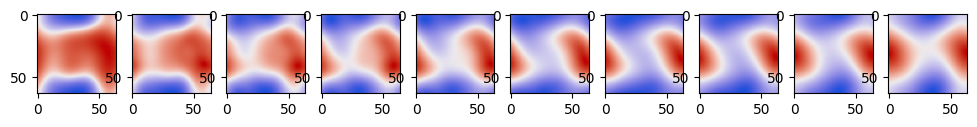

In [30]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol["values"][0, i * 10, 0], cmap=cc.cm.coolwarm)

In [ ]:
dataset = generate_dataset(
    n_coeffs=50,
    n_ics_per_coeff=500,
    pde_factory=Euler2D,
    initial_condition_fn=initial_condition,
    coeff_range_dict={"gamma": (1.2, 5/3)},
    x_span=((0, 1), (0, 1)),
    Nx=(50, 50),
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)


  0%|                                                                                                                                                                     | 0/50 [00:00<?, ?it/s]

In [8]:
dataset["values"].nbytes / 1e9

0.101

In [1]:
dataset["values"].shape


NameError: name 'dataset' is not defined

In [ ]:
from pathlib import Path

savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "2d_euler_training_50_500.hdf5")

In [ ]:
def generate_dataset_incremental(
    n_coeffs: int,
    n_ics_per_coeff: int,
    pde_factory: Callable[[Any], eqx.Module],
    initial_condition_fn: Callable[[Array, PRNGKeyArray], Array],
    coeff_range_dict: dict,
    x_span: tuple[float, float],
    Nx: int,
    t_span: tuple[float, float],
    Nt: int,
    bc: Literal["periodic"] = "periodic",
    dataset_type: Literal["train", "validation", "test"] = "train",
    seed: int = 0,
):

In [ ]:
.venv/bin/python ./scripts/training/train_multiphysics_2d.py \
  data=2d_scalar \
  model=hyperfluxno_2d_scalar_global \
  training.context_length=10 \
  training.batch_size=32 \
  training.optimizer.learning_rate.warmup_steps=10000 \
  training.optimizer.learning_rate.decay_steps=40000 \
  hydra.launcher.partition=h100 \
  hydra.launcher.cpus_per_task=12 \
  hydra.launcher.mem_gb=350 \
  model.key.seed=10 \
  --multirun